<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Jeremias Martin Pantozzi


### Introduccion Ejercicio 1
En este trabajo se estudian distintas señales determinísticas y continuas en el tiempo, sintetizadas con el objetivo de analizar sus propiedades fundamentales: frecuencia, período, cantidad de muestras y su clasificación como señales de energía o de potencia. 

Las señales periódicas, como las senoidales o cuadradas, poseen potencia promedio finita y energía infinita, por lo que se clasifican como señales de potencia. En cambio, señales no periódicas y de duración finita, como un pulso rectangular aislado, presentan energía total finita y potencia promedio nula, clasificándose como señales de energía.

También se incorpora el estudio de la modulación por producto, en la cual la amplitud de una señal se modifica mediante otra de menor frecuencia. La modulación permite transformar el contenido de una señal a través de otra y constituye una operación fundamental en comunicaciones y procesamiento de señales. En este trabajo, la modulación se implementa mediante la multiplicación directa entre señales sinusoidales, lo que genera nuevas componentes espectrales asociadas a la suma y diferencia de sus frecuencias.

Además, se analiza el efecto de saturación, una operación no lineal en la que la amplitud de la señal se limita a un valor máximo permitido. Cuando la señal supera dicho umbral, su valor se recorta y permanece fijo en el límite impuesto. Este fenómeno modela comportamientos reales de dispositivos como amplificadores, conversores o sensores que no pueden exceder ciertos niveles físicos. Matemáticamente, la saturación puede implementarse mediante una función de recorte, como numpy.clip(), que restringe la amplitud dentro de un rango definido


 


### Desarrollo Ejercicio 1

Para este trabajo se propuso sintetizar y analizar distintas señales determinísticas, aplicando sobre ellas operaciones lineales y no lineales con el fin de observar cómo se modifican sus propiedades fundamentales. Las señales generadas fueron las siguientes:

- Una señal sinusoidal de 2 kHz.
- La misma señal amplificada 3 dB y desfasada en \pi /2.
- La misma señal modulada por producto con una señal sinusoidal de 1000 Hz.
- La misma señal sometida a un efecto de saturación al 75% de su amplitud, implementado mediante una función de recorte.
- Una señal cuadrada de 4 kHz.
- Un pulso rectangular de duración 10 ms.

Cada una de estas señales fue sintetizada numéricamente y posteriormente graficada para visualizar su comportamiento temporal. En las figuras se incluyen leyendas que indican sus propiedades principales: frecuencia, período, cantidad de muestras y su clasificación como señal de energía o de potencia, según corresponda.

Para llevar a cabo esta síntesis se implementó el siguiente código en Python, donde se generan las señales solicitadas y se representan gráficamente las distintas transformaciones aplicadas.


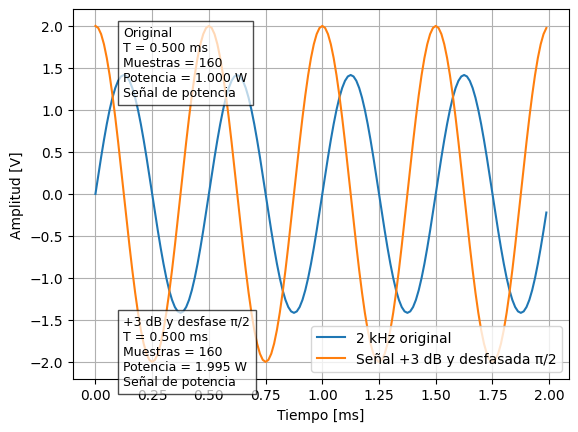

C:\Users\jerem\AppData\Local\Temp\ipykernel_9572\2911825265.py:104: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


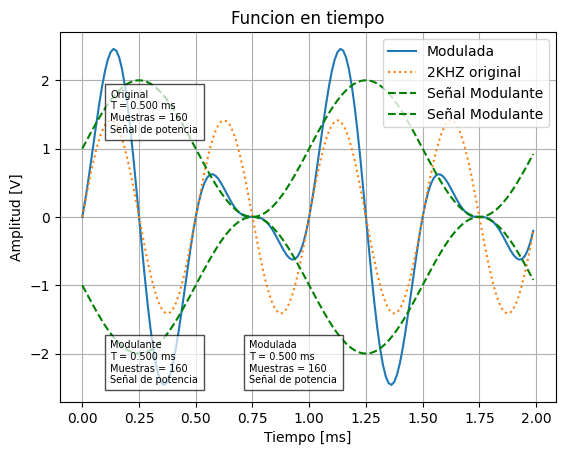

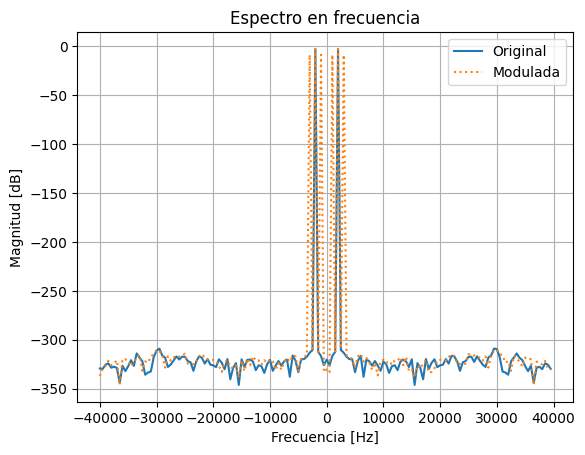

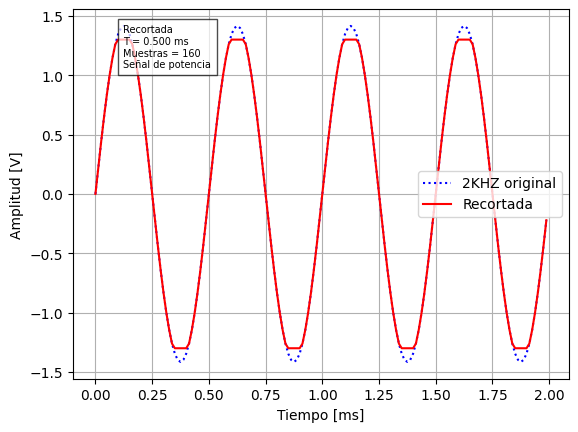

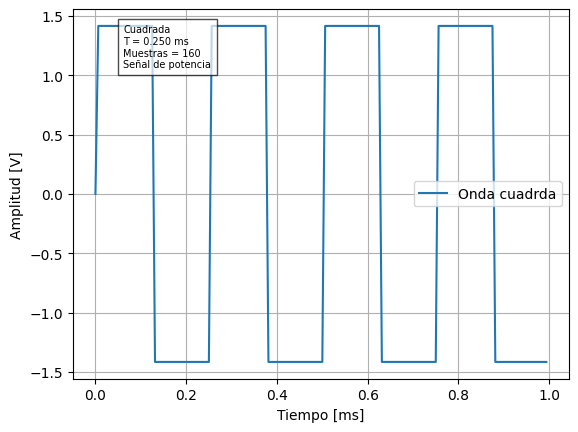

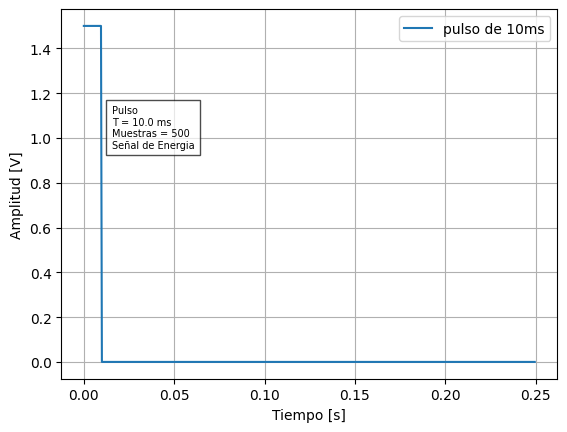

In [3]:
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig
#%% Funciones 

def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
 
def mi_funcion_cua (vmax,ff, nn, fs):
    n = np.arange(nn)
    tt= n/fs
    y= vmax * np.sign(np.sin(2 * np.pi * ff * n / fs))
    return tt, y
def pulso (vmax, T, nn, fs): #vmax: amplitud, T:duracion dle pulso [seg], nn: cantd. muestras, fs: frecuencia de muestreo
    tt = np.arange(nn) / fs
    x = np.where(tt < T, vmax, 0)
    return tt, x

    
#%% Aplicacion

#%%Señal Sen de 2kHz

ff=2000
muestras_xciclo=40 #cantidad de muestras que quiero por ciclo, respetando niquitz minimo necesito 2.
fs=muestras_xciclo*ff #frecuencia de muestreo para respetar las muestras por ciclo
nn= 4*muestras_xciclo #cuantos ciclos quiero visualizar, en este caso 4.

tt,xx=mi_funcion_sen(np.sqrt(2),0,ff,0,nn,fs)



#%%Señal amplificada y desfasada
ph=np.pi/2 #desfase que nos piden
k=10**(3/20) #amplificacion 3dB = 20log(A/A0) 
tt1,xx1=mi_funcion_sen(k*np.sqrt(2),0,ff,ph,nn,fs)

plt.figure(0)
plt.clf()
plt.plot(tt*1000, xx , label='2 kHz original')
plt.plot(tt1*1000, xx1, label='Señal +3 dB y desfasada π/2')
plt.legend()
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

# --- Datos ---
periodo = 1 / ff
tipo_senal = "Señal de potencia"
# Potencias
P1 = (np.sqrt(2)**2) / 2
P2 = (k*np.sqrt(2))**2 / 2

texto_original = (
    f"Original\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Potencia = {P1:.3f} W\n"
    f"Señal de potencia"
)

texto_amp = (
    f"+3 dB y desfase π/2\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Potencia = {P2:.3f} W\n"
    f"Señal de potencia"
)

# Anotación cerca de cada curva
plt.annotate(
    texto_original,
    xy=(tt[int(nn*0.1)], xx[int(nn*0.1)]),
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.annotate(
    texto_amp,
    xy=(tt1[int(nn*0.6)], xx1[int(nn*0.6)]),
    xytext=(20, -40),
    textcoords='offset points',
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.7)
)


plt.show()


#%%Modulacion de sen original con otra de frecuancia 1000Hz (Asumo error de tipeo en consigna 10000Hz no es logico para modular usar una señal de mayor frecuencia que la portadora)
ff2=1000
tt2,xx2=mi_funcion_sen(1,1,ff2,0,nn,fs)

ym= xx*xx2


plt.legend()
plt.figure(1)
plt.clf()
plt.plot(tt*1000,ym, label ='Modulada')
plt.plot(tt*1000, xx , label = '2KHZ original',linestyle='dotted')
plt.plot(tt2*1000, xx2, label = 'Señal Modulante',color='green',linestyle='--')
plt.plot(tt2*1000, -xx2, label = 'Señal Modulante',color='green',linestyle='--')
plt.legend()
plt.title("Funcion en tiempo")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

# --- Datos ---
periodo = 1 / ff
tipo_senal = "Señal de potencia"
# Potencias
P1 = (np.sqrt(2)**2) / 2
P2 = (k*np.sqrt(2))**2 / 2

texto_original = (
    f"Original\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Señal de potencia"
)

texto_amp = (
    f"Modulante\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Señal de potencia"
)
texto_mod = (
    f"Modulada\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Señal de potencia"
)


# Anotación cerca de cada curva
plt.annotate(
    texto_original,
    xy=(tt[int(nn*0.1)], xx[int(nn*0.1)]),
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.annotate(
    texto_amp,
    xy=(tt1[int(nn*0.6)], xx1[int(nn*0.6)]),
    xytext=(20, -40),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.annotate(
    texto_mod,
    xy=(tt1[int(nn*0.6)], xx1[int(nn*0.6)]),
    xytext=(120, -40),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.show()

# FFT
XX = np.fft.fft(xx)/nn
YY = np.fft.fft(ym)/nn

# Frecuencias
freqs = np.fft.fftfreq(len(xx), 1/fs)

# Centrado
XX_shift = np.fft.fftshift(XX)
YY_shift = np.fft.fftshift(YY)
freqs_shift = np.fft.fftshift(freqs)

# Magnitud en dB
XX_dB = 20*np.log10(np.abs(XX_shift))
YY_dB = 20*np.log10(np.abs(YY_shift))

plt.figure()
plt.plot(freqs_shift, XX_dB, label="Original")
plt.plot(freqs_shift, YY_dB, label="Modulada",linestyle='dotted')
plt.grid(True)
plt.legend()
plt.title("Espectro en frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.show()



#%%Señal anterior recortada al 75% de su amplitud. En este caso 75% de raiz de 2

lim=0.75*np.sqrt(3)

y_rec=np.clip(xx, -lim, lim) #uso la funcion clipeo, si la señal xx supera algun limite se reemplaza por el limite

plt.figure(3)
plt.clf()
plt.plot(tt*1000, xx , label = '2KHZ original',color='blue',linestyle='dotted')
plt.plot(tt*1000,y_rec, label ='Recortada', color='red')
plt.legend()
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

texto_recot = (
    f"Recortada\n"
    f"T = {periodo*1000:.3f} ms\n"
    f"Muestras = {nn}\n"
    f"Señal de potencia"
)


# Anotación cerca de cada curva
plt.annotate(
    texto_recot,
    xy=(tt[int(nn*0.1)], xx[int(nn*0.1)]),
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.show()

#%%Onda cuadrada de 4Khz

ffc=4000
muestras_xciclo=40 #cantidad de muestras que quiero por ciclo, respetando niquitz minimo necesito 2.
fsc=muestras_xciclo*ffc #frecuencia de muestreo para respetar las muestras por ciclo
nnc= 4*muestras_xciclo #cuantos ciclos quiero visualizar, en este caso 4.

tc, yc= mi_funcion_cua(np.sqrt(2), ffc, nnc, fsc)

plt.figure(4)
plt.clf()
plt.plot(tc*1000,yc, label ='Onda cuadrda')
plt.legend()
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

# --- Datos ---
periodoc = 1 / ffc
texto_cua = (
    f"Cuadrada\n"
    f"T = {periodoc*1000:.3f} ms\n"
    f"Muestras = {nnc}\n"
    f"Señal de potencia"
)


# Anotación cerca de cada curva
plt.annotate(
    texto_cua,
    xy=(tt[int(nn*0.1)], xx[int(nn*0.1)]),
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.show()


#%% Pulso de 10ms

vmax=1.5
T=10/1000 #10ms a segundos

ttp,yp= pulso(vmax,T,500,2000)

plt.figure(5)
plt.clf()
plt.plot(ttp,yp, label ='pulso de 10ms')
plt.legend()
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True)

# --- Datos ---

texto_puls = (
    f"Pulso\n"
    f"T = {T*1000:.1f} ms\n"
    f"Muestras = {500}\n"
    f"Señal de Energia"
)


# Anotación cerca de cada curva
plt.annotate(
    texto_puls,
    xy=(tt[int(nn*0.1)], xx[int(nn*0.1)]),
    xytext=(20, 20),
    textcoords='offset points',
    fontsize=7,
    bbox=dict(facecolor='white', alpha=0.7)
)
plt.show()

### Conclusion Ejercicio 1
A lo largo del trabajo se sintetizaron y analizaron distintas señales determinísticas, lo que permitió observar de manera práctica cómo se comportan bajo transformaciones lineales y no lineales. La generación de una señal sinusoidal de 2 kHz y sus variantes amplificada y desfasada permitió verificar que las señales periódicas mantienen su período y su clasificación como señales de potencia, aun cuando se modifique su amplitud o fase.
En el dominio del tiempo, la señal modulada muestra cómo la amplitud de la portadora sigue la forma de la modulante, sin alterar su frecuencia fundamental.

La modulación por producto entre la señal de 2 kHz y una señal de 1 kHz evidenció la aparición de nuevas componentes en la suma y diferencia de frecuencias (1 kHz y 3 kHz), mostrando cómo la multiplicación de señales transforma su contenido espectral sin alterar su naturaleza de señal de potencia. Este resultado coincide con el comportamiento teórico esperado para la modulación por producto.

Por otro lado, la aplicación de un recorte al 75% de la amplitud introdujo una distorsión no lineal claramente visible en el dominio temporal. Este efecto de saturación generó una señal periódica pero con forma deformada, lo que en un sistema real se traduciría en la aparición de armónicos adicionales en el espectro. La implementación mediante  permitió reproducir de manera sencilla este fenómeno típico de dispositivos con limitaciones físicas.

La síntesis de una señal cuadrada de 4 kHz reforzó el análisis de señales periódicas de potencia, mientras que el pulso rectangular de 10 ms permitió contrastar con un ejemplo de señal de energía, caracterizada por su duración finita y potencia promedio nula.
